In [48]:
from utils import * 
import numpy as np
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re
import orjson
import ast  
import shutil 
from ppi import get_contacts

%load_ext autoreload 
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]

In [50]:
# Interested in looking at potential protein-protein interactions, particularly potential interactions with the ATPase as a possible hint at function. 

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['alphafold_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{int(row.cluster_id)}_1mer', axis=1)
genes_df = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].copy()

FASTAFile.from_df(genes_df).write('../data/genes/level_1_conserved_clusters.faa')

In [51]:
def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs/'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}
 

In [52]:
names = list() # Store the names of the AlphaFold jobs to access the output directories.
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/ppi-level_1_conserved' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)


for genome_id, df in genes_df.groupby('genome_id'):

    pairs = list(itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2))
    pairs += [(entry, entry) for entry in df.reset_index(names='gene_id').to_dict(orient='records')] # Also add homo-dimers, which are not included in combinations. 
    for pair in pairs:

        alphafold_ids = [ pair[0]['alphafold_id'],  pair[1]['alphafold_id']]
        gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
        seqs = [pair[0]['seq'], pair[1]['seq']]

        name = '-'.join(alphafold_ids)
        names.append(name)
        
        msas = get_msas_unpaired(gene_ids)
        file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=10, version=2)

        for gene_id, alphafold_id, seq in zip(gene_ids, alphafold_ids, seqs):
            file.add_seq(seq, paired_msa="", unpaired_msa=msas[gene_id], description=alphafold_id)

        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))

print('Number of co-folds:', len(names), end='\n\n')

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

Number of co-folds: 442

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi-level_1_conserved/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 10"


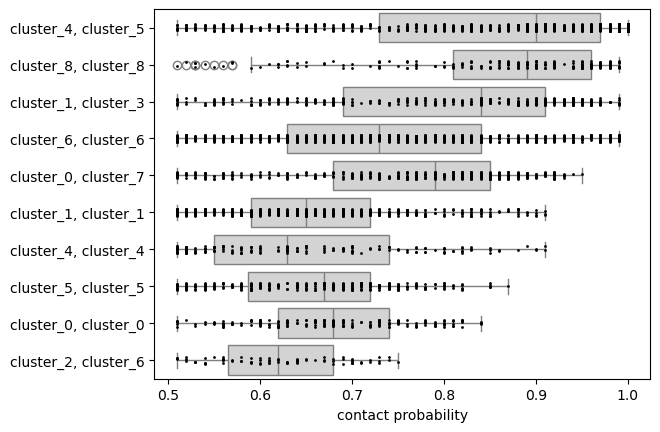

Number of genomes with cluster_0, cluster_0 in contact: 8
Number of genomes with cluster_0, cluster_7 in contact: 10
Number of genomes with cluster_1, cluster_1 in contact: 8
Number of genomes with cluster_1, cluster_3 in contact: 11
Number of genomes with cluster_2, cluster_6 in contact: 6
Number of genomes with cluster_4, cluster_4 in contact: 8
Number of genomes with cluster_4, cluster_5 in contact: 10
Number of genomes with cluster_5, cluster_5 in contact: 7
Number of genomes with cluster_6, cluster_6 in contact: 10
Number of genomes with cluster_8, cluster_8 in contact: 8


In [53]:
if not os.path.exists('analysis-1-ppi-level_1_conserved_contacts.csv'):
    contacts_df = list()
    for name in tqdm(names, desc='Loading contact data.'):
        output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name))
        contacts_df.append(get_contacts(output, min_contact_prob=0.3))
    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv('analysis-1-ppi-level_1_conserved_contacts.csv', index=False)
else:
    contacts_df = pd.read_csv('analysis-1-ppi-level_1_conserved_contacts.csv')


def get_contact_id(row):
    ''''''
    contact_id = sorted([f'{row.chain_id_0}:{row.residue_num_0}', f'{row.chain_id_1}:{row.residue_num_1}'])
    return '-'.join(contact_id)

contacts_df['cluster_ids'] = [', '.join(sorted(re.findall(r'cluster_\d+', name))) for name in contacts_df['name']]
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)
contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)

figure_df = contacts_df.copy()
figure_df = figure_df[figure_df.contact_prob > 0.5].copy()
figure_df['num_genomes'] = figure_df.cluster_ids.map(contacts_df.groupby('cluster_ids').apply(lambda df : df.dropna().genome_id.nunique()))
figure_df = figure_df[figure_df.num_genomes >= 8].copy()
figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['name', 'contact_id'])


fig, ax = plt.subplots()
sns.boxplot(figure_df, y='cluster_ids', x='contact_prob', color='lightgray')
# sns.stripplot(figure_df, y='cluster_ids', x='contact_prob', hue='pae', palette='Grays')
sns.stripplot(figure_df, y='cluster_ids', x='contact_prob', color='black', s=2)
ax.set_ylabel('')
ax.set_xlabel('contact probability')
plt.show()

for cluster_ids, df in figure_df.groupby('cluster_ids'):
    print(f'Number of genomes with {cluster_ids} in contact:', df.genome_id.nunique())

In [54]:
contacts_df[contacts_df.cluster_ids == 'cluster_3, cluster_0']

,idx_0,chain_id_0,residue_num_0,residue_0,seq_0,idx_1,chain_id_1,residue_num_1,residue_1,seq_1,pae,contact_prob,name,model,cluster_ids,contact_id,genome_id


In [55]:
# Even without strong MSAs, it could be informative to look at protein-protein interaction predictions for all supported contacts. 
# It is also possible that proteins with weak folds have stronger structural predictions when co-folded. 

# In order to limit the search space, I will co-fold only ORFs with some support:
#   (1) Predicted by Prodigal, which indicated there is some signal that the region is protein-coding. 
#   (2) Conserved, i.e. detected in at least two genomes. 
#   (3) Has some InterProScan annotation. 
#   (4) Has a valid ColabFold structure (at least 50 consecutive residues with pLDDT > 70)

supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str)

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df.loc[supported_gene_ids].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))

# In order to reduce the runtime (which is astronomical if AlphaFold tries to generate MSAs for each complex), I will re-use
# the ColabFold-generated MSAs, which are already in the required a3m format. 

msas = dict()
for genome_id, df in genes_df.groupby('genome_id'):
    dir_path = os.path.join('../data/genes/colabfold/', genome_id)
    msas.update(get_msas_unpaired(df.index.tolist(), dir_path=dir_path))
# # Remove the comment lines at the beginning of each MSA. 
# msas = {gene_id:'\n'.join(msa.split('\n')[1:]) for gene_id, msa in msas.items()}

counts = np.array([msa.count('>') for msa in msas.values()])
print('Number of MSAs for supported genes with > 5 sequences:', (counts > 6).sum())
print('Number of supported genes:', len(supported_gene_ids))


Number of MSAs for supported genes with > 5 sequences: 107
Number of supported genes: 536


In [56]:
genome_id = 'bz_1'

ALPHAFOLD_INPUT_DIR = f'../data/genes/alphafold/af_input/ppi-{genome_id}'
ALPHAFOLD_OUTPUT_DIR = f'../data/genes/alphafold/af_output/ppi-{genome_id}' 

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

names = list()

df = genes_df[genes_df.genome_id == genome_id]

pairs = list(itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2))
pairs += [(entry, entry) for entry in df.reset_index(names='gene_id').to_dict(orient='records')] # Also add homo-dimers, which are not included in combinations. 
for pair in pairs:

    gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
    seqs = [pair[0]['seq'], pair[1]['seq']]

    name = '-'.join(gene_ids)
    names.append(name)

    file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=3, version=2)

    for gene_id, seq in zip(gene_ids, seqs):
        file.add_seq(seq, paired_msa='', unpaired_msa=msas[gene_id])

    file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))


print('Number of co-folds:', len(names), end='\n\n')

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

Number of co-folds: 946

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi-bz_1/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 5"


In [57]:
if not os.path.exists(f'analysis-1-ppi-{genome_id}_contacts.csv'):
    contacts_df = list()
    for name in tqdm(names, desc='Loading contact data.'):
        output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name))
        contacts_df.append(get_contacts(output, min_contact_prob=0.5))
    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv(f'analysis-1-ppi-{genome_id}_contacts.csv', index=False)
else:
    contacts_df = pd.read_csv(f'analysis-1-ppi-{genome_id}_contacts.csv')

print(f'Number of potential contacts in the {genome_id} genome:', contacts_df.name.nunique())
for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')):
    name = os.path.basename(path)
    if name not in contacts_df.name.unique():
        shutil.rmtree(path)

Loading contact data.:   0%|          | 0/946 [00:00<?, ?it/s]

Loading contact data.:   0%|          | 0/946 [00:00<?, ?it/s]


AssertionError: AlphaFoldOutput._get_confidences: Was unable to find any confidence JSON files in /home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/ppi-bz_1/orfm.bz_1.1_4-orfm.bz_1.1_5.

In [ ]:
cluster_1_gene_id = genes_df[(genes_df.cluster_id == 1) & (genes_df.genome_id == genome_id)].index[0]
cluster_3_gene_id = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id == genome_id)].index[0]

contacts_df[contacts_df.name.str.contains(cluster_1_gene_id)].name.nunique()
contacts_df[contacts_df.name.str.contains(cluster_1_gene_id)]

seq_to_gene_id_map = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
gene_id_to_cluster_id_map = genes_df.cluster_id.to_dict()

contacts_df['gene_id_0'] = contacts_df.seq_0.map(seq_to_gene_id_map)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(seq_to_gene_id_map)
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(gene_id_to_cluster_id_map)
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(gene_id_to_cluster_id_map)

contacts_df = contacts_df.sort_values('contact_prob', ascending=False)
contacts_df['num_models'] = contacts_df.groupby('name').model.transform('nunique')
contacts_df[contacts_df.name.str.contains(cluster_1_gene_id)].drop_duplicates('name')
contacts_df[contacts_df.name.str.contains(cluster_3_gene_id) & (contacts_df.num_models == 3)].drop_duplicates(['name', 'model'])



,idx_0,chain_id_0,residue_num_0,residue_0,seq_0,idx_1,chain_id_1,residue_num_1,residue_1,seq_1,pae,contact_prob,name,model,gene_id_0,gene_id_1,cluster_id_0,cluster_id_1,num_models
4193,17,A,17,Q,MSKEKESLENETGFSEKQTAFITNLFTGKGGIFDRPQGQGGDATND...,216,B,67,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,1.5,0.98,orfm.bz_0.1_175-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_175,orfm.bz_0.1_191,1,3,3
4266,17,A,17,Q,MSKEKESLENETGFSEKQTAFITNLFTGKGGIFDRPQGQGGDATND...,216,B,67,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,1.5,0.98,orfm.bz_0.1_175-orfm.bz_0.1_191,seed-3_sample-0,orfm.bz_0.1_175,orfm.bz_0.1_191,1,3,3
4338,17,A,17,Q,MSKEKESLENETGFSEKQTAFITNLFTGKGGIFDRPQGQGGDATND...,216,B,67,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,1.6,0.98,orfm.bz_0.1_175-orfm.bz_0.1_191,seed-1_sample-0,orfm.bz_0.1_175,orfm.bz_0.1_191,1,3,3
6440,64,A,64,E,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,459,B,200,F,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2.0,0.95,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3,3
6538,200,A,200,F,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,323,B,64,E,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2.1,0.95,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-3_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3,3
6579,64,A,64,E,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,459,B,200,F,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2.0,0.95,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-1_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3,3
1113,80,A,80,L,MKETIIIQNAGDFPVEIRKCIKVDTQIFRLEGKDEAIKHSGKPCIN...,272,B,176,H,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2.2,0.91,orfm.bz_0.1_36-orfm.bz_0.1_191,seed-3_sample-0,orfm.bz_0.1_36,orfm.bz_0.1_191,1434,3,3
3128,9,A,9,I,LNKLNAVEAIVSFIFPPNSCITFSKYLIHSYNPIVSYSRYSLNLSQC,244,B,197,P,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2.4,0.89,orfm.bz_0.1_89-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_89,orfm.bz_0.1_191,17,3,3
1068,77,A,77,I,MKETIIIQNAGDFPVEIRKCIKVDTQIFRLEGKDEAIKHSGKPCIN...,272,B,176,H,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2.2,0.88,orfm.bz_0.1_36-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_36,orfm.bz_0.1_191,1434,3,3
3173,9,A,9,I,LNKLNAVEAIVSFIFPPNSCITFSKYLIHSYNPIVSYSRYSLNLSQC,244,B,197,P,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,3.3,0.88,orfm.bz_0.1_89-orfm.bz_0.1_191,seed-1_sample-0,orfm.bz_0.1_89,orfm.bz_0.1_191,17,3,3


In [ ]:
# if not os.path.exists('analysis-1-ppi_data.json'):
    
#     outputs = [AlphaFoldOutput(path) for path in output_dirs if os.path.exists(path)]

#     data = list()
#     for output in outputs:
#         contact_probs_df = output.get_contact_probs(models=[output.best_model])
#         paes_df =  output.get_paes(models=[output.best_model])
#         chain_ids = ['A', 'B']

#         idxs, idxs_shifted = get_interface_idxs(contact_probs_df, chain_ids=chain_ids, shift=True)
#         idxs = [idxs[chain_ids[0]], idxs[chain_ids[1]]]

#         data_ = {'name':output.name}
#         data_['iptm'] = np.mean(list(output.get_iptms().values()))
#         data_['idxs'] = idxs
#         data_['idxs_shifted'] = [idxs_shifted[chain_ids[0]], idxs_shifted[chain_ids[1]]]
#         data_['num_contacts'] = len(idxs[0])
#         data_['pae'] = [paes_df.iloc[i, j] for i, j in zip(*idxs)]
#         data_['contact_probs'] = [contact_probs_df.iloc[i, j] for i, j in zip(*idxs)]
#         data.append(data_)

#     with open('analysis-1-ppi_data.json', 'wb') as f:
#         f.write(orjson.dumps(data, default=default))

# else:
#     with open('analysis-1-ppi_data.json', 'r') as f:
#         data = json.load(f)

# data = [data_ for data_ in data if (data_['num_contacts'] > 0)]
# print(f'Loaded data for {len(data)} AlphaFold co-folds with predicted contacts.')


In [ ]:
# Jack said that looking at the ipTM is not super informative; there could be a valid protein-protein interaction, but low ipTM due to disordered or low-
# confidence regions. Instead, it would be worth looking at the PAE for residues on different monomers. Any error < 10 A could be worth considering as a potential contact. 

# What would be a good potential statistic for evaluating the likelihood of a protein-protein contact? Want to evaluate both (1) predicted distance and (2) PAE. 
# There is also an output called contact_probs, which is based on a seperate output head in the model (i.e. not the pLDDT or PAE head). This is discussed in the 
# supplement of Jumper et. al. 2021. 

# TODO: Take some notes on this, I don't know if I completely understand. 
# Why isn't PAE symmetric? Asymmetry can arise due to differences in the stability of the selected reference frame. 
# The PAE asks "Asuming this residue is correctly located, how wrong is the other one likely to be?"

In [ ]:
ppis = list()
for path in output_dirs:
    cluster_ids = sorted(re.findall(r'cluster_\d+', path))
    assert len(cluster_ids) == 2, f'Only expected 2 gene clusters per file, but got {len(cluster_ids)}.'
    ppis.append('-'.join(cluster_ids))

ppis, counts = np.unique(ppis, return_counts=True)
for ppi, count in zip(ppis, counts):
    print(ppi, count)

# Would be useful to look at the confidence of the residue positions at the interface, and also whether or not the cluster_1-cluster_3 interactions affect the multimerization. 

cluster_0-cluster_0 11
cluster_0-cluster_1 11
cluster_0-cluster_2 11
cluster_0-cluster_3 11
cluster_0-cluster_4 10
cluster_0-cluster_5 10
cluster_0-cluster_6 10
cluster_0-cluster_7 10
cluster_0-cluster_8 9
cluster_1-cluster_1 11
cluster_1-cluster_2 11
cluster_1-cluster_3 11
cluster_1-cluster_4 10
cluster_1-cluster_5 10
cluster_1-cluster_6 10
cluster_1-cluster_7 10
cluster_1-cluster_8 9
cluster_2-cluster_2 11
cluster_2-cluster_3 11
cluster_2-cluster_4 10
cluster_2-cluster_5 10
cluster_2-cluster_6 10
cluster_2-cluster_7 10
cluster_2-cluster_8 9
cluster_3-cluster_3 11
cluster_3-cluster_4 10
cluster_3-cluster_5 10
cluster_3-cluster_6 10
cluster_3-cluster_7 10
cluster_3-cluster_8 9
cluster_4-cluster_4 10
cluster_4-cluster_5 10
cluster_4-cluster_6 9
cluster_4-cluster_7 9
cluster_4-cluster_8 8
cluster_5-cluster_5 10
cluster_5-cluster_6 9
cluster_5-cluster_7 9
cluster_5-cluster_8 8
cluster_6-cluster_6 10
cluster_6-cluster_7 9
cluster_6-cluster_8 8
cluster_7-cluster_7 10
cluster_7-cluster_8 8
c

In [ ]:
# names = list()
# ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
# ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

# for genome_id, df in genes_df[genes_df.cluster_id.isin([1, 3])].groupby('genome_id'):

#     for pair in itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2):
#         name = pair[0]['alphafold_id'].replace('1mer', '6mer') + '-' + pair[1]['alphafold_id'].replace('1mer', '6mer') + '-mg_atp'
#         names.append(name)

#         gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
#         seqs = [pair[0]['seq'], pair[1]['seq']]

#         msas = dict()
#         msas['unpaired'] = get_msas_unpaired(gene_ids)

#         file = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=1)

#         for gene_id, seq in zip(gene_ids, seqs):
#             file.add_seq(seq, paired_msa=msas['paired'][gene_id], unpaired_msa=msas['unpaired'][gene_id], n=6)
#         file.add_atp(n=6)
#         file.add_mg(n=6)

#         file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))



In [ ]:
# It seems as though the cluster_1-cluster_3 contact is only predicted highly with the cluster_3 monomer. But is this a failing of AlphaFold?
# Do the contacting residues differ between the monomer predictions and the multimer predictions (i.e. does cluster_3 multimerizing block 
# the preferred interface for cluster_1 and cluster_3)?

In [ ]:
# def get_msas_paired(gene_ids:list, dir_path:str=MMSEQS_DIR):
#     '''Construct paired MSAs using the specified gene IDs as queries. This is done by:
#         (1) Loading the unpaired MSA for each query gene ID. 
#         (2) Filtering each unpaired MSA to include only genes from genomes which are represented in both, i.e. contain identified homologs of each query sequence. 
#         (3) Sorting the MSAs alphabetically by gene ID (ensuring the query is still the first entry) so that rows correspond.
        
#     :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
#     :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
#         sequence. 
#     '''
#     assert len(set([get_genome_id(gene_id) for gene_id in gene_ids])) == 1, 'get_msas_paired: Expected all genes to be from the same genome.'

#     paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
#     msas = {gene_id:FASTAFile.from_file(path).to_df().reset_index(names='gene_id') for gene_id, path in paths.items()}
#     msas = {gene_id:df.assign(genome_id=df.gene_id.apply(get_genome_id)) for gene_id, df in msas.items()}

#     genome_ids = None
#     for _, df in msas.items(): # Get all genome IDs which have a representative for all chains. 
#         genome_ids = df.genome_id.unique() if (genome_ids is None) else np.intersect1d(genome_ids, df.genome_id.unique())
    
#     if len(genome_ids) < 2:
#         # If there are two few genome IDs, the paired MSA will just contain the genes from the query genome (but do not want it to throw an error). 
#         print('get_msas_paired: Too few paired sequences for a proper paired MSA.')

#     sort = lambda df : pd.concat([df.iloc[:1], df.iloc[1:].sort_values('gene_id')]) # Sort a DataFrame by genome ID, while holding the query row fixed.
#     msas = {gene_id:sort(df[df.genome_id.isin(genome_ids)].copy()) for gene_id, df in msas.items()}
    
#     return {gene_id:str(FASTAFile.from_df(df.set_index('gene_id'))) for gene_id, df in msas.items()}
